# VacancyFee.org Hackathon â€” Starter Notebook

This notebook loads the hackathon datasets and provides starter code for:
1. Exploring vacant parcel data
2. Making maps
3. Calculating fee revenue projections
4. Analyzing ownership patterns

**Requirements:** `pip install pandas geopandas matplotlib folium`

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Adjust this path to where your data lives
DATA_DIR = '.'  # assumes notebook is in hackathon_data/

# Load vacant parcels (9 MB, fast)
vacant = pd.read_csv(f'{DATA_DIR}/vacant_parcels.csv', low_memory=False)
print(f'Loaded {len(vacant):,} vacant parcels')
print(f'Columns: {list(vacant.columns)}')
vacant.head()

Loaded 28,670 vacant parcels
Columns: ['PARCEL_APN', 'TAXAPN', 'SITE_ADDR', 'SITE_CITY', 'SITE_STATE', 'SITE_ZIP', 'LATITUDE', 'LONGITUDE', 'ASSESSEE_OWNER_NAME_1', 'ASSESSEE_OWNER_NAME_2', 'ASSESSEE_MAIL_CITY', 'ASSESSEE_MAIL_STATE', 'ASSESSEE_MAIL_ZIP', 'VAL_ASSD_LAND', 'VAL_ASSD_IMPRV', 'VAL_ASSD', 'ASMT_YEAR', 'ASMT_RCDRS_DATE_TRANSFER', 'ASMT_VAL_TRANSFER', 'USE_CODE_MUNI_DESC', 'USE_CODE_MUNI', 'USE_CODE_STD_LPS', 'USE_CODE_STD_DESC_LPS', 'ZONING', 'LOT_SIZE_AREA', 'LOT_SIZE_AREA_UNIT', 'LIVING_SQFT', 'YR_BLT', 'BUILDING_SQFT', 'STORIES_NUMBER', 'UNITS_NUMBER', 'BEDROOMS', 'TOTAL_BATHS_CALCULATED', 'VAL_MRKT_LAND', 'VAL_MRKT_IMPRV', 'VAL_MARKET', 'LAST_SALE_DATE_TRANSFER', 'VAL_TRANSFER', 'JURISDICTION', 'H3_INT_9', 'vacancy_tier']


,PARCEL_APN,TAXAPN,SITE_ADDR,SITE_CITY,SITE_STATE,SITE_ZIP,LATITUDE,LONGITUDE,ASSESSEE_OWNER_NAME_1,ASSESSEE_OWNER_NAME_2,...,BEDROOMS,TOTAL_BATHS_CALCULATED,VAL_MRKT_LAND,VAL_MRKT_IMPRV,VAL_MARKET,LAST_SALE_DATE_TRANSFER,VAL_TRANSFER,JURISDICTION,H3_INT_9,vacancy_tier
0,22902730020000,229-0273-002-0000,SHARPS CIR,CARMICHAEL,CA,95608.0,38.671909,-121.320553,RECORE GROWTH INVESTMENTS INC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNINCORPORATED COUNTY,617700322241150975,Tier 2: Zero Improvement
1,22902940260000,229-0294-026-0000,CREEKCREST CIR,CITRUS HEIGHTS,CA,95621.0,38.672503,-121.315296,KING STEVE,NaN,...,NaN,NaN,NaN,NaN,NaN,20130315.0,NaN,UNINCORPORATED COUNTY,617700322241675263,Tier 1: Coded Vacant
2,22904800910000,229-0480-091-0000,GREENBACK LN,CITRUS HEIGHTS,CA,95621.0,38.678303,-121.310979,CITY OF CITRUS HEIGHTS,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNINCORPORATED COUNTY,617700322045853695,Tier 2: Zero Improvement
3,22907000160000,229-0700-016-0000,6630 GREENBACK LN,CITRUS HEIGHTS,CA,95621.0,38.677633,-121.309849,WILLIAM LEVIN CAROLINA LLC (WALGREEN CO),NaN,...,NaN,NaN,NaN,NaN,NaN,20200429.0,5900000.0,UNINCORPORATED COUNTY,617700322045067263,Tier 2: Zero Improvement
4,22907000030000,229-0700-003-0000,6140 DEWEY DR,CITRUS HEIGHTS,CA,95621.0,38.677376,-121.309729,WILLIAM LEVIN CAROLINA LLC (WALGREEN CO),NaN,...,NaN,0.0,NaN,NaN,NaN,20200429.0,5900000.0,UNINCORPORATED COUNTY,617700322045067263,Tier 2: Zero Improvement


## Quick Stats

In [2]:
print('=== Vacancy by Tier ===')
print(vacant['vacancy_tier'].value_counts())
print()

print('=== Top 10 Cities by Vacant Parcel Count ===')
print(vacant['SITE_CITY'].value_counts().head(10))
print()

total_land_value = vacant['VAL_ASSD_LAND'].sum()
print(f'Total assessed land value of vacant parcels: ${total_land_value:,.0f}')
print(f'Current annual revenue at $70/parcel: ${len(vacant) * 70:,.0f}')

=== Vacancy by Tier ===
Tier 1: Coded Vacant         19364
Tier 2: Zero Improvement      9151
Tier 3: Parking/Abandoned      155
Name: vacancy_tier, dtype: int64

=== Top 10 Cities by Vacant Parcel Count ===
SACRAMENTO        12639
ELK GROVE          3771
RANCHO CORDOVA     2997
FOLSOM             2145
GALT               1005
ANTELOPE            622
CARMICHAEL          578
FAIR OAKS           547
CITRUS HEIGHTS      516
RIO LINDA           401
Name: SITE_CITY, dtype: int64

Total assessed land value of vacant parcels: $5,144,484,854
Current annual revenue at $70/parcel: $2,006,900


## Value Distribution

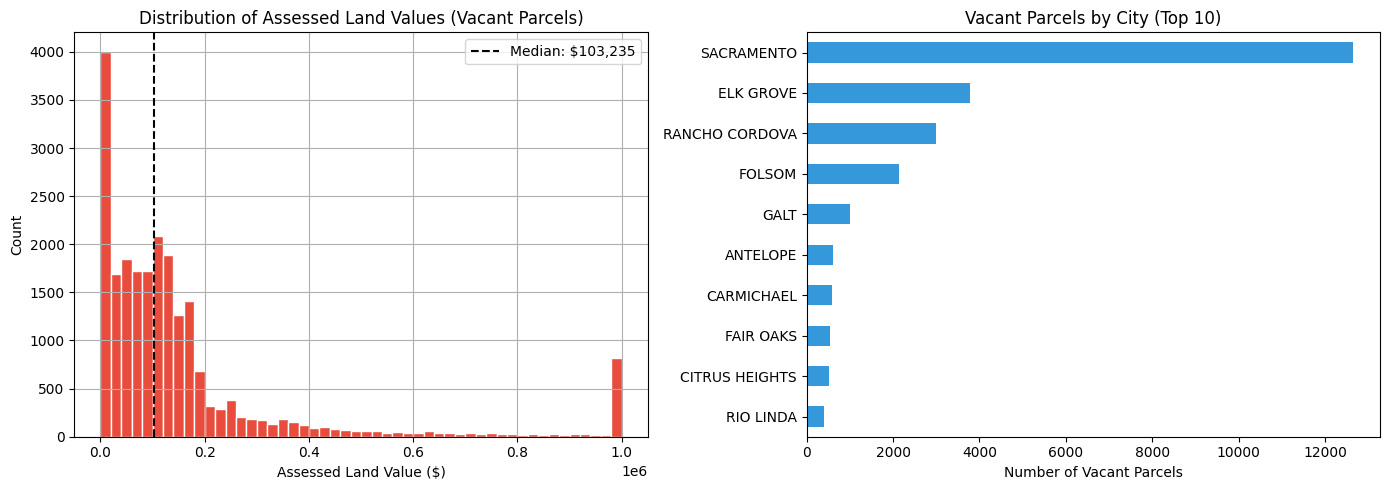

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of land values (cap at $1M for readability)
vacant['VAL_ASSD_LAND'].clip(upper=1_000_000).hist(bins=50, ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Distribution of Assessed Land Values (Vacant Parcels)')
axes[0].set_xlabel('Assessed Land Value ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=vacant['VAL_ASSD_LAND'].median(), color='black', linestyle='--', label=f'Median: ${vacant["VAL_ASSD_LAND"].median():,.0f}')
axes[0].legend()

# Vacant parcels by city (top 10)
city_counts = vacant['SITE_CITY'].value_counts().head(10)
city_counts.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Vacant Parcels by City (Top 10)')
axes[1].set_xlabel('Number of Vacant Parcels')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Fee Revenue Projection

Model revenue under a **square-footage-based graduated fee** that ramps up the longer a property sits vacant.

This fee applies to **parcels with structures** (using `BUILDING_SQFT` or `LIVING_SQFT`). Bare vacant land without buildings remains at the current $70 flat fee.

| Vacancy Duration | Rate per Sq Ft per Month |
| --- | --- |
| 0 to 3 months | $0.00 (grace period) |
| 4 to 6 months | $0.50 |
| 7 to 9 months | $0.75 |
| 10 to 12 months | $1.00 |
| 13 to 24 months | $2.00 |
| 25 to 36 months | $3.00 |
| 37 to 48 months | $4.00 |
| 49+ months | +$1.00 per sqft for each additional 12-month period |

In [ ]:
import numpy as np

# --- Fee schedule ---
def monthly_rate(months_vacant):
    """Return the per-sqft monthly fee rate based on vacancy duration."""
    if months_vacant <= 3:
        return 0.00
    elif months_vacant <= 6:
        return 0.50
    elif months_vacant <= 9:
        return 0.75
    elif months_vacant <= 12:
        return 1.00
    elif months_vacant <= 24:
        return 2.00
    else:
        # $2 base at 24 months, +$1 per subsequent 12-month period
        extra_years = (months_vacant - 24 - 1) // 12 + 1
        return 2.00 + extra_years * 1.00

def annual_fee(sqft, months_vacant):
    """Calculate total annual fee for a parcel given building sqft and vacancy duration."""
    if pd.isna(sqft) or sqft <= 0 or pd.isna(months_vacant):
        return 0.0
    rate = monthly_rate(months_vacant)
    return sqft * rate * 12

# --- Identify parcels with buildings (sqft-based fee applies to these) ---
# Use BUILDING_SQFT, fall back to LIVING_SQFT
vacant['billable_sqft'] = vacant['BUILDING_SQFT'].where(
    vacant['BUILDING_SQFT'].notna() & (vacant['BUILDING_SQFT'] > 0),
    vacant['LIVING_SQFT']
)

has_bldg = vacant['billable_sqft'].notna() & (vacant['billable_sqft'] > 0)
bare_land = ~has_bldg

print(f'Parcels with building sqft (graduated fee): {has_bldg.sum():,}')
print(f'Bare land parcels (flat $70 fee):           {bare_land.sum():,}')
print(f'Total:                                      {len(vacant):,}')
print()
print(f'Building sqft stats (parcels with structures):')
bldg = vacant.loc[has_bldg, 'billable_sqft']
print(f'  Median: {bldg.median():,.0f} sqft')
print(f'  Mean:   {bldg.mean():,.0f} sqft')
print(f'  Min:    {bldg.min():,.0f} sqft')
print(f'  Max:    {bldg.max():,.0f} sqft')

In [ ]:
# --- Scenario modeling: what if all building parcels have been vacant X months? ---
# Bare land parcels stay at $70 flat fee in all scenarios
bare_land_revenue = bare_land.sum() * 70

print('=== Annual Revenue by Assumed Vacancy Duration ===')
print(f'  ({has_bldg.sum():,} building parcels at graduated rate + {bare_land.sum():,} bare land at $70)')
print()
print(f'{"Duration":<15} {"Rate/sqft/mo":<15} {"Bldg Revenue":<18} {"+ Bare Land":<15} {"Total":<18} {"Avg/Parcel"}')
print('-' * 95)

scenario_data = []
for months in [3, 6, 9, 12, 18, 24, 36, 48, 60]:
    rate = monthly_rate(months)
    bldg_revenue = (vacant.loc[has_bldg, 'billable_sqft'] * rate * 12).sum()
    total = bldg_revenue + bare_land_revenue
    avg = total / len(vacant)
    print(f'{months:>3} months      ${rate:<13.2f} ${bldg_revenue:>14,.0f}   ${bare_land_revenue:>11,.0f}   ${total:>14,.0f}   ${avg:>8,.0f}')
    scenario_data.append({'months': months, 'rate': rate, 'bldg_revenue': bldg_revenue, 'total': total})

scenarios = pd.DataFrame(scenario_data)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scenarios['months'].astype(str), scenarios['total'] / 1e6, color='#e74c3c', edgecolor='white')
ax.set_xlabel('Months Vacant (assumed for all building parcels)')
ax.set_ylabel('Projected Annual Revenue ($ millions)')
ax.set_title('Annual Fee Revenue by Vacancy Duration Scenario')
current_rev = len(vacant) * 70
ax.axhline(y=current_rev / 1e6, color='grey', linestyle='--', label=f'Current $70 flat fee: ${current_rev/1e6:.1f}M')
ax.legend()
for i, row in scenarios.iterrows():
    if row['total'] > 0:
        ax.text(i, row['total']/1e6 + 0.3, f'${row["total"]/1e6:.1f}M', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Estimate Revenue Using Last Sale Date as Duration Proxy

`LAST_SALE_DATE_TRANSFER` gives a rough proxy for how long a property has been idle. Combined with building sqft, this produces a per-parcel fee estimate. Bare land stays at $70.

In [ ]:
# --- Estimate vacancy duration from last sale date ---
today = pd.Timestamp('2026-03-01')

vacant['last_sale_date'] = pd.to_datetime(
    vacant['LAST_SALE_DATE_TRANSFER'].dropna().astype(int).astype(str),
    format='%Y%m%d', errors='coerce'
)
vacant['months_since_sale'] = ((today - vacant['last_sale_date']).dt.days / 30.44).round(0)

# Graduated fee for buildings, flat $70 for bare land
vacant['est_annual_fee'] = vacant.apply(
    lambda r: annual_fee(r['billable_sqft'], r['months_since_sale'])
              if (not pd.isna(r['billable_sqft']) and r['billable_sqft'] > 0)
              else 70,
    axis=1
)

bldg_with_est = has_bldg & vacant['months_since_sale'].notna()
print(f'Building parcels with date estimate: {bldg_with_est.sum():,} / {has_bldg.sum():,}')
print(f'Bare land parcels (flat $70):        {bare_land.sum():,}')
print()

total_revenue = vacant['est_annual_fee'].sum()
print('=== Revenue Estimate (buildings use last-sale-date proxy, bare land at $70) ===')
print(f'Building parcel fees:    ${vacant.loc[has_bldg, "est_annual_fee"].sum():>15,.0f}')
print(f'Bare land fees ($70):    ${vacant.loc[bare_land, "est_annual_fee"].sum():>15,.0f}')
print(f'Total annual revenue:    ${total_revenue:>15,.0f}')
print(f'Current flat fee ($70):  ${len(vacant) * 70:>15,.0f}')
print(f'Revenue multiplier:      {total_revenue / (len(vacant) * 70):>15.1f}x')
print()

# Stats for building parcels only
est_bldg = vacant.loc[has_bldg & (vacant['est_annual_fee'] > 0), 'est_annual_fee']
if len(est_bldg) > 0:
    print('=== Fee Stats (building parcels only) ===')
    print(f'Median annual fee:  ${est_bldg.median():>10,.0f}')
    print(f'Mean annual fee:    ${est_bldg.mean():>10,.0f}')
    print(f'Max annual fee:     ${est_bldg.max():>10,.0f}')
    print()

# Distribution chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

est_all = vacant.loc[vacant['est_annual_fee'] > 70, 'est_annual_fee']
if len(est_all) > 0:
    est_all.clip(upper=100000).hist(bins=50, ax=axes[0], color='#e74c3c', edgecolor='white')
    axes[0].set_title('Distribution of Annual Fees (Building Parcels)')
    axes[0].set_xlabel('Annual Fee ($)')
    axes[0].set_ylabel('Count')
    axes[0].axvline(x=70, color='blue', linestyle='--', linewidth=2, label='Current $70 fee')
    if len(est_bldg) > 0:
        axes[0].axvline(x=est_bldg.median(), color='black', linestyle='--', label=f'Median: ${est_bldg.median():,.0f}')
    axes[0].legend()

# Revenue by tier
tier_rev = vacant.groupby('vacancy_tier')['est_annual_fee'].sum()
tier_rev.plot(kind='barh', ax=axes[1], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Total Revenue by Vacancy Tier')
axes[1].set_xlabel('Annual Revenue ($)')
for i, v in enumerate(tier_rev):
    axes[1].text(v + tier_rev.max()*0.02, i, f'${v/1e6:.1f}M', va='center')

plt.tight_layout()
plt.show()

## Interactive Map with Folium

This creates an interactive web map. We'll plot a sample to keep it fast.

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Filter to Sacramento city, Tier 1, and sample for performance
sac_vacant = vacant[
    (vacant['SITE_CITY'] == 'SACRAMENTO') & 
    (vacant['vacancy_tier'] == 'Tier 1: Coded Vacant') &
    (vacant['LATITUDE'].notna())
].copy()

# Sample if too many points
if len(sac_vacant) > 2000:
    sac_vacant = sac_vacant.sample(2000, random_state=42)

print(f'Mapping {len(sac_vacant)} parcels in Sacramento...')

# Create map centered on Sacramento
m = folium.Map(location=[38.58, -121.49], zoom_start=11, tiles='CartoDB positron')
cluster = MarkerCluster().add_to(m)

for _, row in sac_vacant.iterrows():
    popup_text = f"""
    <b>{row['SITE_ADDR']}</b><br>
    Land Value: ${row['VAL_ASSD_LAND']:,.0f}<br>
    Use: {row['USE_CODE_MUNI_DESC']}<br>
    Lot Size: {row['LOT_SIZE_AREA']}<br>
    Zoning: {row['ZONING']}
    """
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=4,
        popup=folium.Popup(popup_text, max_width=250),
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(cluster)

m

## Ownership Analysis

In [1]:
# Top owners by parcel count
owner_counts = vacant.groupby('ASSESSEE_OWNER_NAME_1').agg(
    parcel_count=('PARCEL_APN', 'count'),
    total_land_value=('VAL_ASSD_LAND', 'sum'),
    avg_land_value=('VAL_ASSD_LAND', 'mean')
).sort_values('parcel_count', ascending=False)

print('=== Top 15 Owners of Vacant Land (by parcel count) ===')
print(owner_counts.head(15).to_string())
print()

print('=== Top 15 Owners of Vacant Land (by total value) ===')
top_value = owner_counts.sort_values('total_land_value', ascending=False).head(15)
print(top_value.to_string())

NameError: name 'vacant' is not defined

## Load GeoPackage (for geometry-based analysis)

In [ ]:
# This loads the simplified GeoPackage with all parcels + joined attributes
# Takes ~30 seconds to load
gdf = gpd.read_file(f'{DATA_DIR}/parcels_simplified.gpkg')
print(f'Loaded {len(gdf):,} parcels with geometry')

# Filter to vacant
gdf_vacant = gdf[gdf['is_vacant_coded'] == True]
print(f'Vacant parcels with geometry: {len(gdf_vacant):,}')

# Quick map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf.plot(ax=ax, color='lightgrey', linewidth=0.1)
gdf_vacant.plot(ax=ax, color='red', linewidth=0.2, alpha=0.6)
ax.set_title('Sacramento County â€” Vacant Parcels (Red)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Next Steps

Ideas to explore from here:
- Build a Streamlit dashboard: `pip install streamlit` then `streamlit run app.py`
- Correlate vacancy with 311 calls: load `SacCounty_SalesForce311_calls.gpkg`
- Analyze out-of-state ownership using `ASSESSEE_MAIL_STATE`
- Overlay council districts to show vacancy by political district
- Compare vacancy patterns to building permits or new construction